<a href="https://colab.research.google.com/github/BickNutler/Data-Science-Capstone-Two/blob/main/04_Modelling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ================================
# 0. Install dependencies (Colab)
# ================================
!pip install -q optuna lightgbm xgboost

# ================================
# 1. Imports
# ================================
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

import lightgbm as lgb
import xgboost as xgb
import optuna
import os

from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    log_loss,
    confusion_matrix,
    classification_report,
    precision_recall_curve,
    average_precision_score,
    roc_curve,
)

import matplotlib.pyplot as plt
import seaborn as sns

# For nicer printing
from pprint import pprint

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 6.4 MB/s eta 0:00:00


In [2]:
# ================================
# 1. Download preprocessed data from GitHub (raw)
import os
import requests

REPO_RAW_BASE_CANDIDATES = [
    # Candidate 1: files directly under 'Preprocessed Data'
    "https://raw.githubusercontent.com/BickNutler/Data-Science-Capstone-Two/main/Preprocessed%20Data",
    # Candidate 2: if you saved into a subfolder (recommended)
    "https://raw.githubusercontent.com/BickNutler/Data-Science-Capstone-Two/main/Preprocessed%20Data/Binning_Configs_Full",
    # Candidate 3: if you used a different folder name
    "https://raw.githubusercontent.com/BickNutler/Data-Science-Capstone-Two/main/Preprocessed%20Data/Binning_Configs_Full/",
]

CONFIG_NAMES = [
    "no_binning",
    "occupation_binned",
    "relationship_binned",
    "workclass_binned",
    "occupation_relationship_binned",
    "occupation_workclass_binned",
    "relationship_workclass_binned",
    "all_binned",
]

OUT_DIR = "preprocessed_from_github"
os.makedirs(OUT_DIR, exist_ok=True)

def _try_download(url: str, out_path: str) -> bool:
    r = requests.get(url, timeout=60)
    if r.status_code == 200 and len(r.content) > 0:
        with open(out_path, "wb") as f:
            f.write(r.content)
        return True
    return False

def download_preprocessed_files():
    needed_files = ["y.csv"] + [f"X_{name}.csv" for name in CONFIG_NAMES]
    for base in REPO_RAW_BASE_CANDIDATES:
        base = base.rstrip("/")
        ok_all = True
        for fn in needed_files:
            url = f"{base}/{fn}"
            out_path = os.path.join(OUT_DIR, fn)
            if not os.path.exists(out_path):
                ok = _try_download(url, out_path)
            else:
                ok = True
            if not ok:
                ok_all = False
                break
        if ok_all:
            print(f"Downloaded preprocessed files from: {base}")
            return base
    raise FileNotFoundError(
        "Could not download the expected files from GitHub. "
        "Expected 'y.csv' and 'X_<config>.csv' files under one of these paths:\n"
        + "\n".join(REPO_RAW_BASE_CANDIDATES)
        + "\n\nIf your filenames or folder differ, update REPO_RAW_BASE_CANDIDATES/CONFIG_NAMES accordingly."
    )

raw_base_used = download_preprocessed_files()


Downloaded preprocessed files from: https://raw.githubusercontent.com/BickNutler/Data-Science-Capstone-Two/main/Preprocessed%20Data


In [3]:
# ================================
# 2. Define binning combo names
#
# ================================
COMBOS = [
    "no_binning",
    "occupation_binned",
    "relationship_binned",
    "workclass_binned",
    "occupation_relationship_binned",
    "occupation_workclass_binned",
    "relationship_workclass_binned",
    "all_binned"
]


In [4]:
# ================================
# 2. Load y and define helpers to load each binning configuration

import pandas as pd
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42
TEST_SIZE = 0.2

y_path = os.path.join(OUT_DIR, "y.csv")
y = pd.read_csv(y_path)["income_>50K"].astype(int)

print("y shape:", y.shape)
print("y positive rate:", y.mean().round(4))

def load_X_config(name: str) -> pd.DataFrame:
    path = os.path.join(OUT_DIR, f"X_{name}.csv")
    return pd.read_csv(path)

def load_and_split(name: str):
    X_full = load_X_config(name)
    X_train, X_test, y_train, y_test = train_test_split(
        X_full, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
    )
    return X_train, X_test, y_train, y_test


y shape: (48842,)
y positive rate: 0.2393


In [5]:
# ================================
# 3. Helper: load config, plus basic sanity checks

def load_combo(combo_name: str):
    if combo_name not in CONFIG_NAMES:
        raise ValueError(f"Unknown combo '{combo_name}'. Expected one of: {CONFIG_NAMES}")
    X_train, X_test, y_train, y_test = load_and_split(combo_name)
    print(f"[{combo_name}] X_train: {X_train.shape} | X_test: {X_test.shape}")
    return X_train, X_test, y_train, y_test

# Quick sanity check
_ = load_combo("no_binning")


[no_binning] X_train: (39073, 41) | X_test: (9769, 41)


In [6]:
# ================================
# 5. Preprocessor builder
#    - Only scales: age, education-num, hours-per-week
#    - log1p + scales: capital-gain, capital-loss
#    - Everything else: passthrough
# ================================
BASE_NUM_COLS = ["age", "education-num", "hours-per-week"]
CAP_COLS = ["capital-gain", "capital-loss"]

def make_preprocessor(feature_names):
    """
    Build a ColumnTransformer that:
      - StandardScaler on ['age', 'education-num', 'hours-per-week']
      - log1p + StandardScaler on ['capital-gain', 'capital-loss']
      - remainder='passthrough' for all other columns
    """
    base_num_cols = [c for c in BASE_NUM_COLS if c in feature_names]
    cap_cols = [c for c in CAP_COLS if c in feature_names]

    base_num_pipeline = Pipeline([
        ("scaler", StandardScaler())
    ])

    cap_pipeline = Pipeline([
        ("log1p", FunctionTransformer(np.log1p, validate=False)),
        ("scaler", StandardScaler())
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("base_num", base_num_pipeline, base_num_cols),
            ("cap", cap_pipeline, cap_cols),
        ],
        remainder="passthrough"
    )

    return preprocessor



In [7]:


# ================================
# 6. Model factory for Optuna
# ================================
def create_model(trial, model_type: str):
    """
    Given an Optuna trial and model_type ('lgbm' or 'xgb'),
    suggest hyperparameters and return a configured model instance.
    """

    if model_type == "lgbm":
        # LightGBM hyperparams
        num_leaves = trial.suggest_int("lgbm_num_leaves", 16, 256, log=True)
        max_depth = trial.suggest_int("lgbm_max_depth", 3, 16)
        learning_rate = trial.suggest_float("lgbm_learning_rate", 1e-3, 0.2, log=True)
        n_estimators = trial.suggest_int("lgbm_n_estimators", 100, 500)
        min_child_samples = trial.suggest_int("lgbm_min_child_samples", 10, 200)
        subsample = trial.suggest_float("lgbm_subsample", 0.6, 1.0)
        colsample_bytree = trial.suggest_float("lgbm_colsample_bytree", 0.6, 1.0)
        reg_alpha = trial.suggest_float("lgbm_reg_alpha", 0.0, 1.0)
        reg_lambda = trial.suggest_float("lgbm_reg_lambda", 0.0, 1.0)

        model = lgb.LGBMClassifier(
            objective="binary",
            boosting_type="gbdt",
            num_leaves=num_leaves,
            max_depth=max_depth,
            learning_rate=learning_rate,
            n_estimators=n_estimators,
            min_child_samples=min_child_samples,
            subsample=subsample,
            colsample_bytree=colsample_bytree,
            reg_alpha=reg_alpha,
            reg_lambda=reg_lambda,
            n_jobs=-1,
            random_state=42
        )

    elif model_type == "xgb":
        # XGBoost hyperparams
        max_depth = trial.suggest_int("xgb_max_depth", 3, 16)
        learning_rate = trial.suggest_float("xgb_learning_rate", 1e-3, 0.2, log=True)
        n_estimators = trial.suggest_int("xgb_n_estimators", 100, 500)
        min_child_weight = trial.suggest_float("xgb_min_child_weight", 1e-1, 10.0, log=True)
        subsample = trial.suggest_float("xgb_subsample", 0.6, 1.0)
        colsample_bytree = trial.suggest_float("xgb_colsample_bytree", 0.6, 1.0)
        reg_alpha = trial.suggest_float("xgb_reg_alpha", 0.0, 1.0)
        reg_lambda = trial.suggest_float("xgb_reg_lambda", 0.0, 1.0)

        model = xgb.XGBClassifier(
            objective="binary:logistic",
            eval_metric="auc",
            max_depth=max_depth,
            learning_rate=learning_rate,
            n_estimators=n_estimators,
            min_child_weight=min_child_weight,
            subsample=subsample,
            colsample_bytree=colsample_bytree,
            reg_alpha=reg_alpha,
            reg_lambda=reg_lambda,
            n_jobs=-1,
            random_state=42,
            tree_method="hist"
        )

    else:
        raise ValueError(f"Unknown model_type: {model_type}")

    return model



In [8]:

# ================================
# 7. Optuna objective function
# ================================
def make_objective(X_train_combo, y_train, combo_name):
    """
    Returns an Optuna objective function bound to a particular
    (X_train_combo, y_train) dataset.
    """

    feature_names = X_train_combo.columns

    def objective(trial):
        # Choose which model to use in this trial
        model_type = trial.suggest_categorical("model_type", ["lgbm", "xgb"])

        # Build preprocessor & model
        preprocessor = make_preprocessor(feature_names)
        model = create_model(trial, model_type)

        # Pipeline: Preprocessing + Model
        pipe = Pipeline([
            ("prep", preprocessor),
            ("clf", model)
        ])

        # Stratified K-Fold
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

        # Use ROC AUC as scoring metric (change if you prefer accuracy, etc.)
        scores = cross_val_score(
            pipe,
            X_train_combo,
            y_train,
            cv=skf,
            scoring="roc_auc",
            n_jobs=-1
        )

        mean_score = scores.mean()
        trial.set_user_attr("combo_name", combo_name)
        trial.set_user_attr("model_type", model_type)

        return mean_score

    return objective



In [9]:

# ================================
# 8. Run Optuna for each combo and track the overall best
# ================================
overall_best = {
    "combo_name": None,
    "score": -np.inf,
    "model_type": None,
    "params": None,
}

studies = {}

for combo_name in COMBOS:
    print(f"\n============================")
    print(f" Tuning combo: {combo_name}")
    print(f"============================")

    # Load this combination's training & test data
    X_train_combo, X_test_combo, y_train_combo, y_test_combo = load_combo(combo_name)

    # Build Optuna study for this combo
    study = optuna.create_study(
        direction="maximize",
        study_name=f"study_{combo_name}"
    )

    objective = make_objective(X_train_combo, y_train_combo, combo_name)

    # You can increase n_trials for more thorough tuning
    study.optimize(objective, n_trials=25, show_progress_bar=True)

    best_trial = study.best_trial
    best_score = best_trial.value
    best_model_type = best_trial.user_attrs["model_type"]

    print(f"\nBest CV ROC AUC for combo '{combo_name}': {best_score:.4f}")
    print(f"Best model type: {best_model_type}")
    print("Best params:")
    pprint(best_trial.params)

    studies[combo_name] = study

    # Track overall best across all combos
    if best_score > overall_best["score"]:
        overall_best["score"] = best_score
        overall_best["combo_name"] = combo_name
        overall_best["model_type"] = best_model_type
        overall_best["params"] = best_trial.params

print("\n======================================")
print("Overall best configuration across all combos:")
pprint(overall_best)
print("======================================")



 Tuning combo: no_binning


[I 2025-12-12 20:16:17,233] A new study created in memory with name: study_no_binning


[no_binning] X_train: (39073, 41) | X_test: (9769, 41)


  0%|          | 0/25 [00:00<?, ?it/s]

[I 2025-12-12 20:16:31,357] Trial 0 finished with value: 0.9273367933266371 and parameters: {'model_type': 'xgb', 'xgb_max_depth': 8, 'xgb_learning_rate': 0.12944346055327624, 'xgb_n_estimators': 110, 'xgb_min_child_weight': 6.8899536336558524, 'xgb_subsample': 0.6413089276663618, 'xgb_colsample_bytree': 0.6240072073502744, 'xgb_reg_alpha': 0.05493114497516949, 'xgb_reg_lambda': 0.039011851930747854}. Best is trial 0 with value: 0.9273367933266371.
[I 2025-12-12 20:16:43,885] Trial 1 finished with value: 0.925407929149524 and parameters: {'model_type': 'xgb', 'xgb_max_depth': 9, 'xgb_learning_rate': 0.12155270624896172, 'xgb_n_estimators': 186, 'xgb_min_child_weight': 1.705623624334571, 'xgb_subsample': 0.8997532070612207, 'xgb_colsample_bytree': 0.6588672293574359, 'xgb_reg_alpha': 0.11684034644704322, 'xgb_reg_lambda': 0.2690558878202921}. Best is trial 0 with value: 0.9273367933266371.
[I 2025-12-12 20:17:03,966] Trial 2 finished with value: 0.9136287406439971 and parameters: {'mode

...

[I 2025-12-12 20:51:02,970] Trial 0 finished with value: 0.9281478339246977 and parameters: {'model_type': 'lgbm', 'lgbm_num_leaves': 175, 'lgbm_max_depth': 6, 'lgbm_learning_rate': 0.08191760217954966, 'lgbm_n_estimators': 498, 'lgbm_min_child_samples': 187, 'lgbm_subsample': 0.8337644739458738, 'lgbm_colsample_bytree': 0.8156171163102945, 'lgbm_reg_alpha': 0.1604336314668816, 'lgbm_reg_lambda': 0.8197897059426762}. Best is trial 0 with value: 0.9281478339246977.
[I 2025-12-12 20:51:32,372] Trial 1 finished with value: 0.9138548062381749 and parameters: {'model_type': 'xgb', 'xgb_max_depth': 15, 'xgb_learning_rate': 0.03195676531606011, 'xgb_n_estimators': 423, 'xgb_min_child_weight': 0.3042537475774365, 'xgb_subsample': 0.6639095631251608, 'xgb_colsample_bytree': 0.905452462389574, 'xgb_reg_alpha': 0.08111297358756397, 'xgb_reg_lambda': 0.12229792731454792}. Best is trial 0 with value: 0.9281478339246977.
[I 2025-12-12 20:51:58,328] Trial 2 finished with value: 0.9175352452777652 and

[I 2025-12-12 20:58:27,864] A new study created in memory with name: study_all_binned


[all_binned] X_train: (39073, 28) | X_test: (9769, 28)


  0%|          | 0/25 [00:00<?, ?it/s]

[I 2025-12-12 20:58:46,964] Trial 0 finished with value: 0.9219443536520144 and parameters: {'model_type': 'xgb', 'xgb_max_depth': 13, 'xgb_learning_rate': 0.0317636524063451, 'xgb_n_estimators': 381, 'xgb_min_child_weight': 0.2226822336213037, 'xgb_subsample': 0.7879705749949446, 'xgb_colsample_bytree': 0.7503086246872857, 'xgb_reg_alpha': 0.4024860774547572, 'xgb_reg_lambda': 0.9388633535442628}. Best is trial 0 with value: 0.9219443536520144.
[I 2025-12-12 20:58:57,078] Trial 1 finished with value: 0.9178296934193796 and parameters: {'model_type': 'xgb', 'xgb_max_depth': 10, 'xgb_learning_rate': 0.004548110310687744, 'xgb_n_estimators': 294, 'xgb_min_child_weight': 6.472001958856599, 'xgb_subsample': 0.6244278056664341, 'xgb_colsample_bytree': 0.9972056594060369, 'xgb_reg_alpha': 0.07914176241678439, 'xgb_reg_lambda': 0.5709071121030017}. Best is trial 0 with value: 0.9219443536520144.
[I 2025-12-12 20:59:14,871] Trial 2 finished with value: 0.8971346916662191 and parameters: {'mode

In [10]:

# ================================
# 9. Retrain best model on full training data and evaluate on the matching test set
# ================================
best_combo = overall_best["combo_name"]
best_model_type = overall_best["model_type"]
best_params = overall_best["params"]

print(f"\nRetraining best model on full training data for combo '{best_combo}'...")

X_train_best, X_test_best, y_train_best, y_test_best = load_combo(best_combo)

# Rebuild preprocessor and model
preprocessor_best = make_preprocessor(X_train_best.columns)
model_best = create_model(optuna.trial.FixedTrial(best_params), best_model_type)

final_pipe = Pipeline([
    ("prep", preprocessor_best),
    ("clf", model_best)
])

# Fit on all training data
final_pipe.fit(X_train_best, y_train_best)

# Evaluate on held-out test set
y_proba_test = final_pipe.predict_proba(X_test_best)[:, 1]
y_pred_test = (y_proba_test >= 0.5).astype(int)

test_auc = roc_auc_score(y_test_best, y_proba_test)
test_acc = accuracy_score(y_test_best, y_pred_test)

print(f"\nFinal Test ROC AUC ({best_combo}, {best_model_type}): {test_auc:.4f}")
print(f"Final Test Accuracy ({best_combo}, {best_model_type}): {test_acc:.4f}")



Retraining best model on full training data for combo 'relationship_binned'...
[relationship_binned] X_train: (39073, 40) | X_test: (9769, 40)
[LightGBM] [Info] Number of positive: 9349, number of negative: 29724
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002659 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 425
[LightGBM] [Info] Number of data points in the train set: 39073, number of used features: 37
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.239270 -> initscore=-1.156685
[LightGBM] [Info] Start training from score -1.156685
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



Final Test ROC AUC (relationship_binned, lgbm): 0.9315
Final Test Accuracy (relationship_binned, lgbm): 0.8777


In [11]:
all_trial_data = []

for combo_name, study in studies.items():
    for trial in study.trials:
        trial_info = {
            "combo_name": trial.user_attrs.get("combo_name"),
            "model_type": trial.user_attrs.get("model_type"),
            "roc_auc_score": trial.value,
            "hyperparameters": trial.params,
        }
        all_trial_data.append(trial_info)

results_df = pd.DataFrame(all_trial_data)

print("DataFrame 'results_df' created successfully.")
print(results_df.head())

DataFrame 'results_df' created successfully.
   combo_name model_type  roc_auc_score  \
0  no_binning        xgb       0.927337   
1  no_binning        xgb       0.925408   
2  no_binning        xgb       0.913629   
3  no_binning        xgb       0.923055   
4  no_binning       lgbm       0.890643   

                                     hyperparameters  
0  {'model_type': 'xgb', 'xgb_max_depth': 8, 'xgb...  
1  {'model_type': 'xgb', 'xgb_max_depth': 9, 'xgb...  
2  {'model_type': 'xgb', 'xgb_max_depth': 16, 'xg...  
3  {'model_type': 'xgb', 'xgb_max_depth': 14, 'xg...  
4  {'model_type': 'lgbm', 'lgbm_num_leaves': 19, ...  


In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

# Group by combo_name and model_type and find the maximum ROC AUC score
best_scores_df = results_df.groupby(['combo_name', 'model_type'])['roc_auc_score'].max().reset_index()

print("DataFrame 'best_scores_df' created successfully.")
print(best_scores_df.head())

DataFrame 'best_scores_df' created successfully.
          combo_name model_type  roc_auc_score
0         all_binned       lgbm       0.927703
1         all_binned        xgb       0.922998
2         no_binning       lgbm       0.928770
3         no_binning        xgb       0.929338
4  occupation_binned       lgbm       0.928392


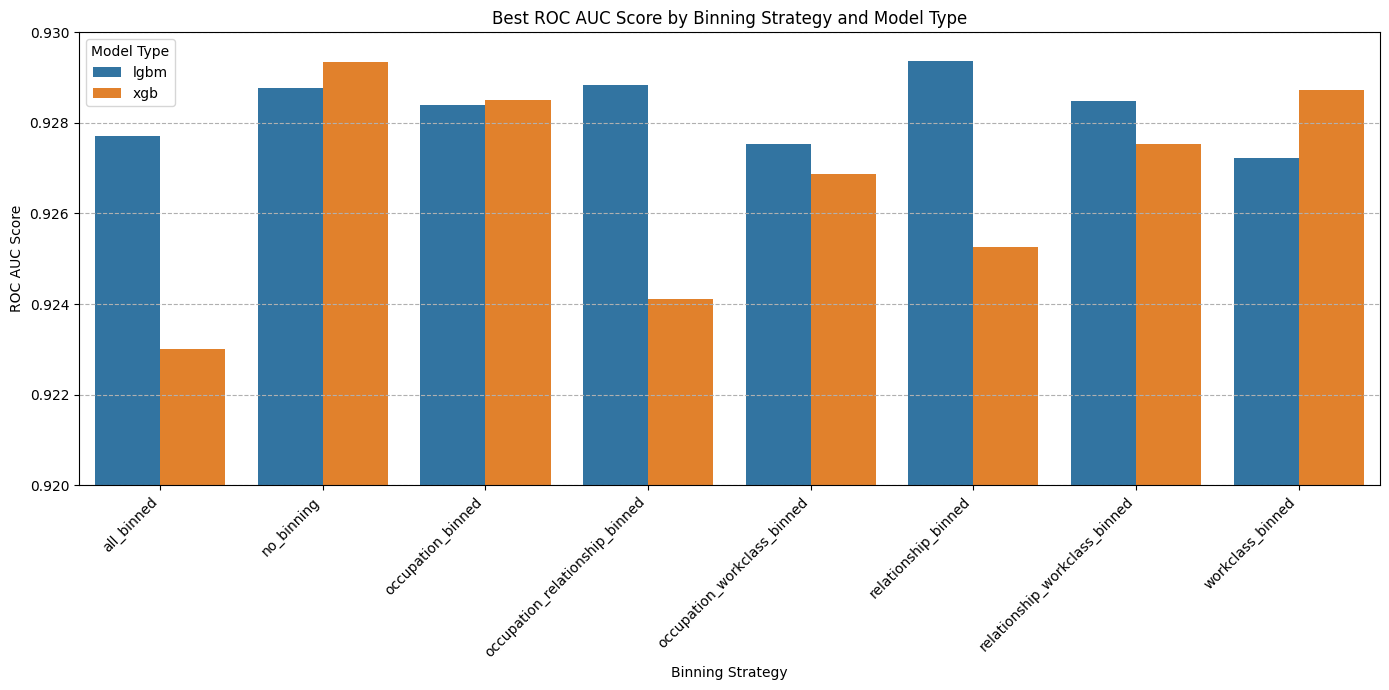

Grouped bar chart visualizing best ROC AUC scores generated successfully.


In [13]:
plt.figure(figsize=(14, 7))
sns.barplot(data=best_scores_df, x='combo_name', y='roc_auc_score', hue='model_type')
plt.title('Best ROC AUC Score by Binning Strategy and Model Type')
plt.xlabel('Binning Strategy')
plt.ylabel('ROC AUC Score')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Model Type')

# Set the y-axis limits
plt.ylim(0.92, 0.93)

plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

print("Grouped bar chart visualizing best ROC AUC scores generated successfully.")

Contents of results_df (first 5 rows):

   combo_name model_type  roc_auc_score  \
0  no_binning        xgb       0.927337   
1  no_binning        xgb       0.925408   
2  no_binning        xgb       0.913629   
3  no_binning        xgb       0.923055   
4  no_binning       lgbm       0.890643   

                                     hyperparameters  
0  {'model_type': 'xgb', 'xgb_max_depth': 8, 'xgb...  
1  {'model_type': 'xgb', 'xgb_max_depth': 9, 'xgb...  
2  {'model_type': 'xgb', 'xgb_max_depth': 16, 'xg...  
3  {'model_type': 'xgb', 'xgb_max_depth': 14, 'xg...  
4  {'model_type': 'lgbm', 'lgbm_num_leaves': 19, ...  

ROC AUC score distribution across all trials:

count    200.000000
mean       0.921988
std        0.008380
min        0.885674
25%        0.918849
50%        0.925734
75%        0.927535
max        0.929362
Name: roc_auc_score, dtype: float64


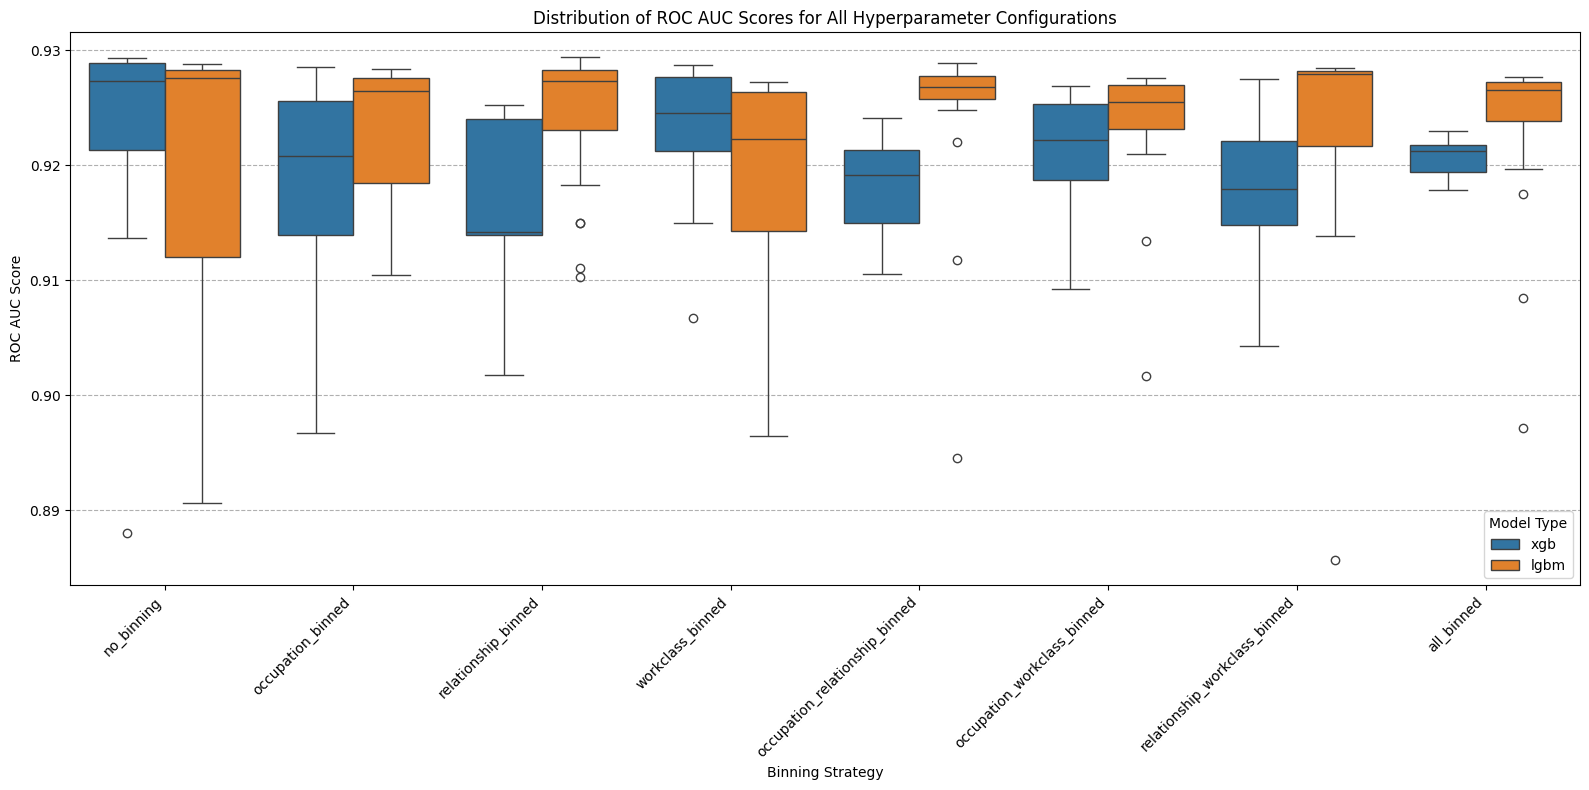

Box plot showing ROC AUC score distribution for all trials generated successfully.


In [14]:
# Display the first few rows of the DataFrame containing all trial results
print("Contents of results_df (first 5 rows):\n")
print(results_df.head())

# Display basic statistics of ROC AUC scores across all trials
print("\nROC AUC score distribution across all trials:\n")
print(results_df['roc_auc_score'].describe())

import matplotlib.pyplot as plt
import seaborn as sns

# Plotting the distribution of ROC AUC scores for all trials
plt.figure(figsize=(16, 8))
sns.boxplot(data=results_df, x='combo_name', y='roc_auc_score', hue='model_type')
plt.title('Distribution of ROC AUC Scores for All Hyperparameter Configurations')
plt.xlabel('Binning Strategy')
plt.ylabel('ROC AUC Score')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Model Type')
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

print("Box plot showing ROC AUC score distribution for all trials generated successfully.")

In [15]:
# results_df has columns: combo_name, model_type, roc_auc_score, hyperparameters

# Get the index of the best trial (highest ROC AUC) for each (combo_name, model_type)
best_idx = results_df.groupby(['combo_name', 'model_type'])['roc_auc_score'].idxmax()

# DataFrame of best hyperparameter sets per combo + model
winners_df = results_df.loc[best_idx].reset_index(drop=True)

print("Best trial per (binning combo, model type):")
print(winners_df[['combo_name', 'model_type', 'roc_auc_score']])


Best trial per (binning combo, model type):
                        combo_name model_type  roc_auc_score
0                       all_binned       lgbm       0.927703
1                       all_binned        xgb       0.922998
2                       no_binning       lgbm       0.928770
3                       no_binning        xgb       0.929338
4                occupation_binned       lgbm       0.928392
5                occupation_binned        xgb       0.928505
6   occupation_relationship_binned       lgbm       0.928840
7   occupation_relationship_binned        xgb       0.924115
8      occupation_workclass_binned       lgbm       0.927540
9      occupation_workclass_binned        xgb       0.926879
10             relationship_binned       lgbm       0.929362
11             relationship_binned        xgb       0.925264
12   relationship_workclass_binned       lgbm       0.928481
13   relationship_workclass_binned        xgb       0.927533
14                workclass_binned       

In [16]:
eval_rows = []
roc_curves = {}
pr_curves = {}

for _, row in winners_df.iterrows():
    combo_name = row['combo_name']
    model_type = row['model_type']
    params = row['hyperparameters']

    print(f"\n=== Evaluating best {model_type} for combo '{combo_name}' ===")

    # Load X for this binning combo
    X_train_combo, X_test_combo, y_train_combo, y_test_combo = load_combo(combo_name)

    # Build preprocessor for these features
    preprocessor = make_preprocessor(X_train_combo.columns)

    # Recreate the best model using FixedTrial with the stored params
    fixed_trial = optuna.trial.FixedTrial(params)
    model = create_model(fixed_trial, model_type)

    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model),
    ])

    # Fit on the full training set for this combo
    pipe.fit(X_train_combo, y_train_combo)

    # Predict on held-out test set
    y_proba = pipe.predict_proba(X_test_combo)[:, 1]
    y_pred = (y_proba >= 0.5).astype(int)

    # Compute metrics
    roc_auc = roc_auc_score(y_test_combo, y_proba)
    acc = accuracy_score(y_test_combo, y_pred)
    prec = precision_score(y_test_combo, y_pred, zero_division=0)
    rec = recall_score(y_test_combo, y_pred, zero_division=0)
    f1 = f1_score(y_test_combo, y_pred, zero_division=0)
    ll = log_loss(y_test_combo, y_proba)
    avg_prec = average_precision_score(y_test_combo, y_proba)

    eval_rows.append({
        "combo_name": combo_name,
        "model_type": model_type,
        "roc_auc": roc_auc,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "log_loss": ll,
        "avg_precision": avg_prec,
    })

    # Store curves for plotting later
    fpr, tpr, _ = roc_curve(y_test_combo, y_proba)
    prec_curve, rec_curve, _ = precision_recall_curve(y_test_combo, y_proba)

    roc_curves[(combo_name, model_type)] = (fpr, tpr)
    pr_curves[(combo_name, model_type)] = (rec_curve, prec_curve)

# Collect metrics into a DataFrame and sort by ROC AUC
eval_df = pd.DataFrame(eval_rows).sort_values("roc_auc", ascending=False).reset_index(drop=True)

print("\nEvaluation metrics for best models per combo + model:")
print(eval_df)



=== Evaluating best lgbm for combo 'all_binned' ===
[all_binned] X_train: (39073, 28) | X_test: (9769, 28)
[LightGBM] [Info] Number of positive: 9349, number of negative: 29724
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005443 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 405
[LightGBM] [Info] Number of data points in the train set: 39073, number of used features: 27
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.239270 -> initscore=-1.156685
[LightGBM] [Info] Start training from score -1.156685
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



=== Evaluating best xgb for combo 'all_binned' ===
[all_binned] X_train: (39073, 28) | X_test: (9769, 28)

=== Evaluating best lgbm for combo 'no_binning' ===
[no_binning] X_train: (39073, 41) | X_test: (9769, 41)
[LightGBM] [Info] Number of positive: 9349, number of negative: 29724
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002747 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 427
[LightGBM] [Info] Number of data points in the train set: 39073, number of used features: 38
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.239270 -> initscore=-1.156685
[LightGBM] [Info] Start training from score -1.156685
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[Lig

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



=== Evaluating best xgb for combo 'no_binning' ===
[no_binning] X_train: (39073, 41) | X_test: (9769, 41)

=== Evaluating best lgbm for combo 'occupation_binned' ===
[occupation_binned] X_train: (39073, 33) | X_test: (9769, 33)
[LightGBM] [Info] Number of positive: 9349, number of negative: 29724
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005432 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 413
[LightGBM] [Info] Number of data points in the train set: 39073, number of used features: 31
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.239270 -> initscore=-1.156685
[LightGBM] [Info] Start training from score -1.156685
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive g

...


=== Evaluating best xgb for combo 'relationship_binned' ===
[relationship_binned] X_train: (39073, 40) | X_test: (9769, 40)

=== Evaluating best lgbm for combo 'relationship_workclass_binned' ===
[relationship_workclass_binned] X_train: (39073, 36) | X_test: (9769, 36)
[LightGBM] [Info] Number of positive: 9349, number of negative: 29724
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003014 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 419
[LightGBM] [Info] Number of data points in the train set: 39073, number of used features: 34
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.239270 -> initscore=-1.156685
[LightGBM] [Info] Start training from score -1.156685
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



=== Evaluating best xgb for combo 'relationship_workclass_binned' ===
[relationship_workclass_binned] X_train: (39073, 36) | X_test: (9769, 36)

=== Evaluating best lgbm for combo 'workclass_binned' ===
[workclass_binned] X_train: (39073, 37) | X_test: (9769, 37)
[LightGBM] [Info] Number of positive: 9349, number of negative: 29724
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002714 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 421
[LightGBM] [Info] Number of data points in the train set: 39073, number of used features: 35
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.239270 -> initscore=-1.156685
[LightGBM] [Info] Start training from score -1.156685
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No furth

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



=== Evaluating best xgb for combo 'workclass_binned' ===
[workclass_binned] X_train: (39073, 37) | X_test: (9769, 37)

Evaluation metrics for best models per combo + model:
                        combo_name model_type   roc_auc  accuracy  precision  \
0                       no_binning        xgb  0.931575  0.876548   0.790256   
1              relationship_binned       lgbm  0.931489  0.877674   0.791433   
2   occupation_relationship_binned       lgbm  0.931456  0.876548   0.790256   
3                 workclass_binned        xgb  0.931281  0.876753   0.787817   
4                occupation_binned        xgb  0.931206  0.876446   0.793461   
5                occupation_binned       lgbm  0.931132  0.876139   0.789825   
6                       no_binning       lgbm  0.930848  0.876344   0.786511   
7    relationship_workclass_binned       lgbm  0.930792  0.876241   0.787570   
8                       all_binned       lgbm  0.930265  0.874092   0.782653   
9    relationship_workclas

In [17]:
best_model_row = eval_df.iloc[0]

print("\n==============================")
print("Overall best model on TEST SET")
print("==============================")
print(best_model_row)

print(f"\nBest model details:\n"
      f"  Binning combo : {best_model_row['combo_name']}\n"
      f"  Model type    : {best_model_row['model_type']}\n"
      f"  ROC AUC       : {best_model_row['roc_auc']:.4f}\n"
      f"  Accuracy      : {best_model_row['accuracy']:.4f}\n"
      f"  Precision     : {best_model_row['precision']:.4f}\n"
      f"  Recall        : {best_model_row['recall']:.4f}\n"
      f"  F1            : {best_model_row['f1']:.4f}\n"
      f"  Avg Precision : {best_model_row['avg_precision']:.4f}\n"
      f"  Log Loss      : {best_model_row['log_loss']:.4f}")



Overall best model on TEST SET
combo_name       no_binning
model_type              xgb
roc_auc            0.931575
accuracy           0.876548
precision          0.790256
recall              0.65911
f1                  0.71875
log_loss           0.270534
avg_precision      0.836895
Name: 0, dtype: object

Best model details:
  Binning combo : no_binning
  Model type    : xgb
  ROC AUC       : 0.9316
  Accuracy      : 0.8765
  Precision     : 0.7903
  Recall        : 0.6591
  F1            : 0.7188
  Avg Precision : 0.8369
  Log Loss      : 0.2705


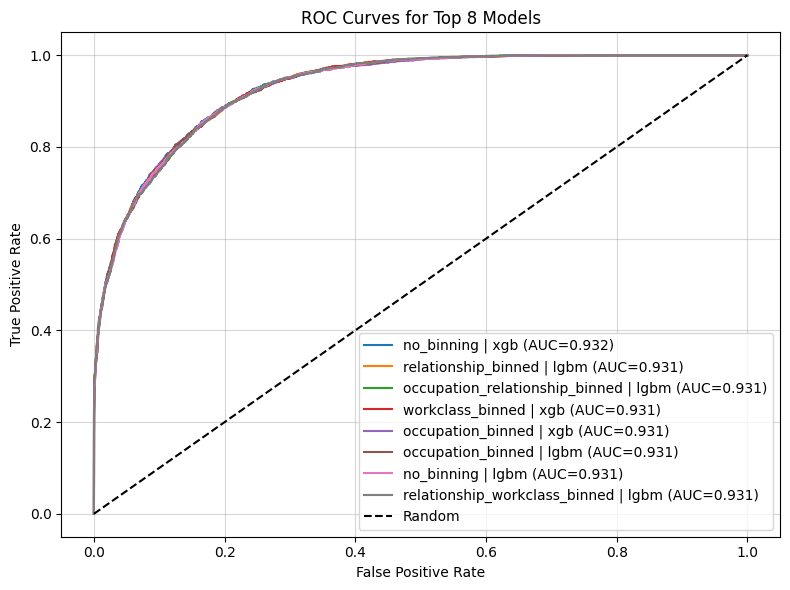

In [18]:
# How many top models to show (to keep curves readable)
TOP_K = 8

top_models = eval_df.head(TOP_K)

plt.figure(figsize=(8, 6))
for _, row in top_models.iterrows():
    key = (row["combo_name"], row["model_type"])
    fpr, tpr = roc_curves[key]
    plt.plot(
        fpr,
        tpr,
        label=f"{row['combo_name']} | {row['model_type']} (AUC={row['roc_auc']:.3f})"
    )

plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.title(f"ROC Curves for Top {TOP_K} Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(alpha=0.5)
plt.tight_layout()
plt.show()


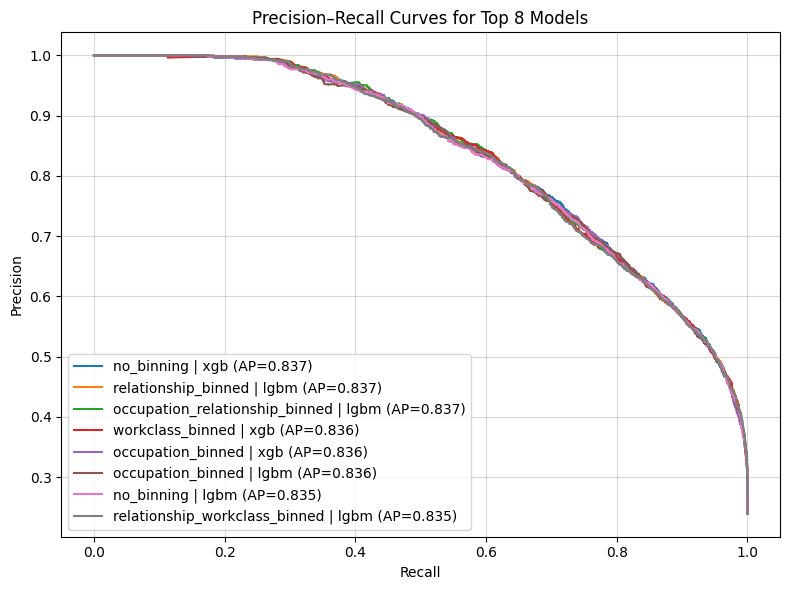

In [19]:
plt.figure(figsize=(8, 6))
for _, row in top_models.iterrows():
    key = (row["combo_name"], row["model_type"])
    rec_curve, prec_curve = pr_curves[key]
    plt.plot(
        rec_curve,
        prec_curve,
        label=f"{row['combo_name']} | {row['model_type']} (AP={row['avg_precision']:.3f})"
    )

plt.title(f"Precision–Recall Curves for Top {TOP_K} Models")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend(loc="lower left")
plt.grid(alpha=0.5)
plt.tight_layout()
plt.show()


In [21]:
# ================================
# Export full metrics table
# ================================
import pandas as pd

if 'eval_rows' not in globals():
    raise NameError("Expected `eval_rows` (list of metric dicts) to exist. Re-run the evaluation cells above.")

final_model_metrics_full = pd.DataFrame(eval_rows)

# Enforce consistent column order (matches the committed artifact)
desired_cols = ['combo_name', 'model_type', 'roc_auc', 'accuracy', 'precision', 'recall', 'f1', 'log_loss', 'avg_precision']
missing = [c for c in desired_cols if c not in final_model_metrics_full.columns]
if missing:
    raise ValueError(f"`final_model_metrics_full` is missing expected columns: {missing}")

final_model_metrics_full = final_model_metrics_full[desired_cols].sort_values(['combo_name','model_type']).reset_index(drop=True)

final_model_metrics_full.to_csv("final_model_metrics_full.csv", index=False)
print("Wrote final_model_metrics_full.csv with shape:", final_model_metrics_full.shape)

Wrote final_model_metrics_full.csv with shape: (16, 9)
